# ICT619 Artificial Intelligence
## Machine Learning-Based Predictive Maintenance System
**WestMine Resources**

**Team:** Bishal Neopaney (35108802) · Ugyen Dorji (35415731) · Binisha Sherchan (35440353)

**Models:** Random Forest & XGBoost | **Dataset:** AI4I 2020 Predictive Maintenance

## Cell 1 – Install & Import Libraries

In [ ]:
!pip install xgboost scikit-learn imbalanced-learn matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Cell 2 – Load Dataset
Loaded directly from the GitHub repository.

In [ ]:
# Load dataset directly from GitHub
url = "https://raw.githubusercontent.com/0xbishal/ict691/main/ai4i2020.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumn names:", list(df.columns))
df.head()

Dataset shape: (10000, 14)

Column names: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Cell 3 – Exploratory Data Analysis (EDA)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

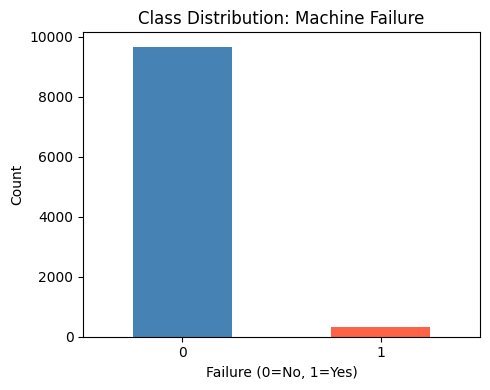

In [ ]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution (Machine Failure) ===")
print(df['Machine failure'].value_counts())
print(f"Failure rate: {df['Machine failure'].mean()*100:.2f}%")

# Class imbalance bar chart
plt.figure(figsize=(5, 4))
df['Machine failure'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution: Machine Failure')
plt.xlabel('Failure (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

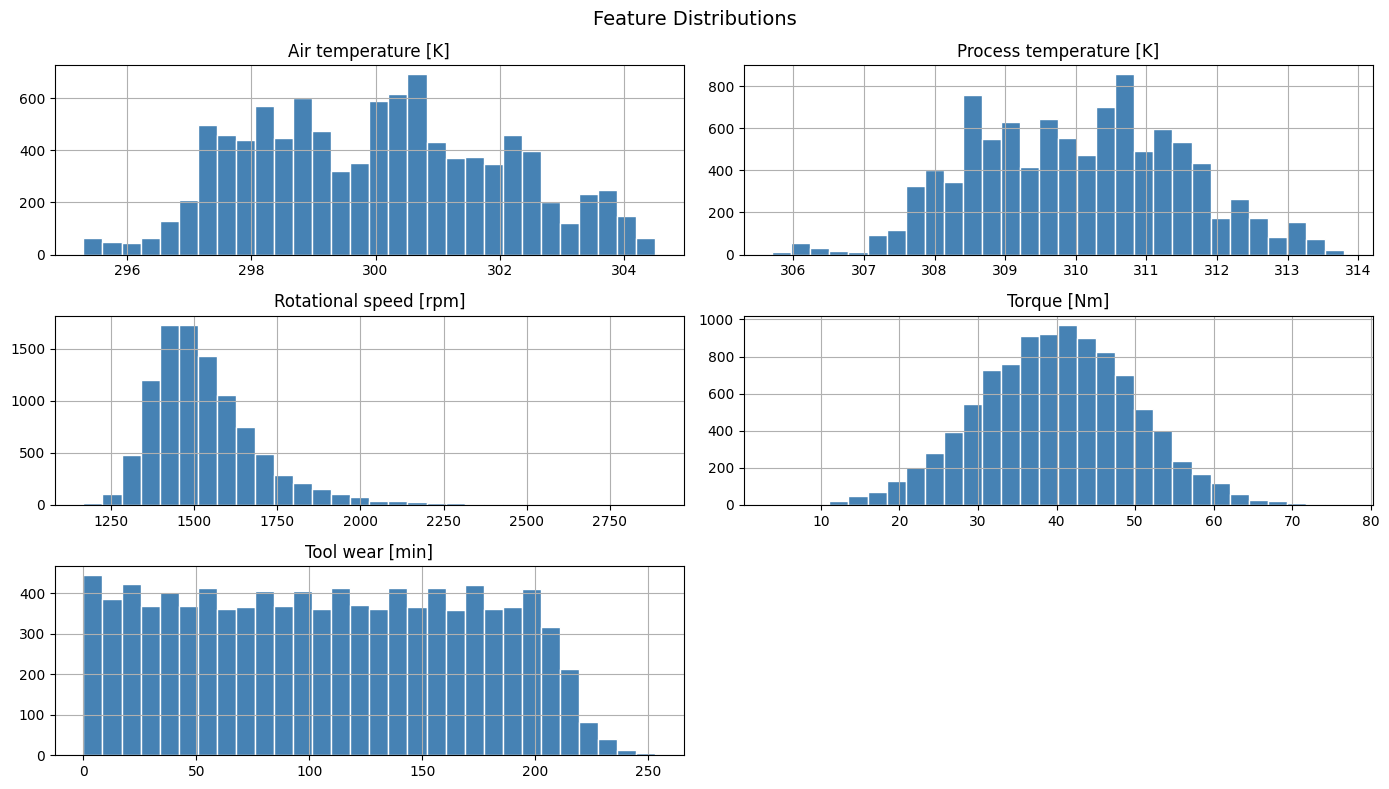

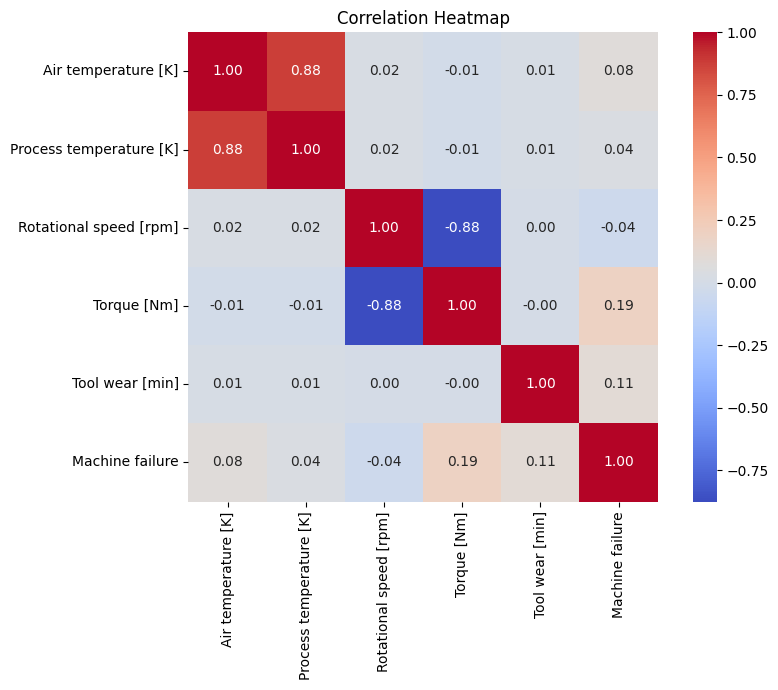

In [ ]:
# Feature distributions
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[features].hist(figsize=(14, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(9, 7))
corr = df[features + ['Machine failure']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Cell 4 – Preprocessing

In [ ]:
# Drop non-informative columns and sub-failure modes
drop_cols     = ['UDI', 'Product ID']
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=drop_cols + failure_modes)

# Encode 'Type' column (L / M / H → 0 / 1 / 2)
le = LabelEncoder()
df_clean['Type'] = le.fit_transform(df_clean['Type'])
print("Encoded Type classes:", list(le.classes_))

# Define features and target
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

# Normalise features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Fix column names for XGBoost compatibility (remove [ ] < characters)
X_scaled.columns = X_scaled.columns.str.replace(r'[\[\]<]', '', regex=True).str.strip()
X.columns = X_scaled.columns  # keep X in sync for feature importance labels

print("\nFeature columns:", list(X_scaled.columns))
print("Target distribution:\n", y.value_counts())
print("\nPreprocessing complete")

Encoded Type classes: ['H', 'L', 'M']

Feature columns: ['Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min']
Target distribution:
 Machine failure
0    9661
1     339
Name: count, dtype: int64

Preprocessing complete


## Cell 5 – Train/Test Split & SMOTE (Handle Class Imbalance)

In [ ]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Before SMOTE → Class 0: {sum(y_train_raw==0)}, Class 1: {sum(y_train_raw==1)}")
print(f"After  SMOTE → Class 0: {sum(y_train==0)},     Class 1: {sum(y_train==1)}")
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Before SMOTE → Class 0: 7729, Class 1: 271
After  SMOTE → Class 0: 7729,     Class 1: 7729

Train size: 15458 | Test size: 2000


## Cell 6 – Train Random Forest

In [ ]:
print("=== Training Random Forest ===")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1')
print(f"\nCross-Val F1 scores: {cv_scores_rf.round(4)}")
print(f"Mean CV F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest training complete")

=== Training Random Forest ===

Cross-Val F1 scores: [0.9681 0.9635 0.9663 0.969  0.967 ]
Mean CV F1: 0.9668 ± 0.0019

Random Forest training complete


## Cell 7 – Train XGBoost

In [ ]:
print("=== Training XGBoost ===")

scale_pos = sum(y_train == 0) / sum(y_train == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1')
print(f"\nCross-Val F1 scores: {cv_scores_xgb.round(4)}")
print(f"Mean CV F1: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost training complete")

=== Training XGBoost ===

Cross-Val F1 scores: [0.9855 0.9849 0.9823 0.9878 0.9853]
Mean CV F1: 0.9852 ± 0.0017

XGBoost training complete


## Cell 8 – Evaluation Metrics

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {name} – Evaluation Report")
    print(f"{'='*50}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=['No Failure', 'Failure']))

evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate_model("XGBoost",       y_test, y_pred_xgb, y_prob_xgb)


  Random Forest – Evaluation Report
  Accuracy : 0.9500
  Precision: 0.3919
  Recall   : 0.8529
  F1-Score : 0.5370
  ROC-AUC  : 0.9738

Classification Report:

              precision    recall  f1-score   support

  No Failure       0.99      0.95      0.97      1932
     Failure       0.39      0.85      0.54        68

    accuracy                           0.95      2000
   macro avg       0.69      0.90      0.76      2000
weighted avg       0.97      0.95      0.96      2000


  XGBoost – Evaluation Report
  Accuracy : 0.9740
  Precision: 0.5870
  Recall   : 0.7941
  F1-Score : 0.6750
  ROC-AUC  : 0.9775

Classification Report:

              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.59      0.79      0.68        68

    accuracy                           0.97      2000
   macro avg       0.79      0.89      0.83      2000
weighted avg       0.98      0.97      0.98      2000



## Cell 9 – Confusion Matrices

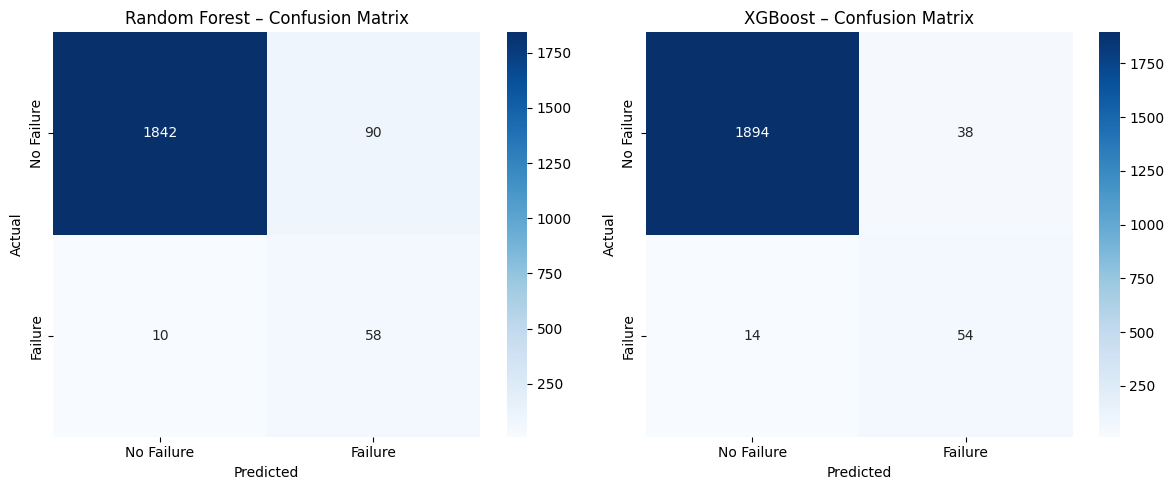

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in zip(axes,
                             ['Random Forest', 'XGBoost'],
                             [y_pred_rf, y_pred_xgb]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    ax.set_title(f'{name} – Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Cell 10 – ROC Curves

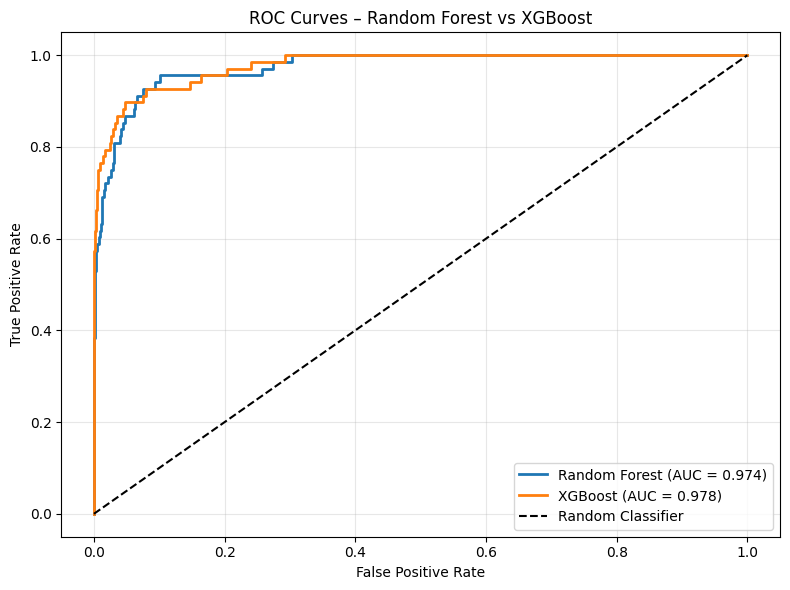

In [ ]:
plt.figure(figsize=(8, 6))

for name, y_prob in [('Random Forest', y_prob_rf), ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Random Forest vs XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 11 – Feature Importance

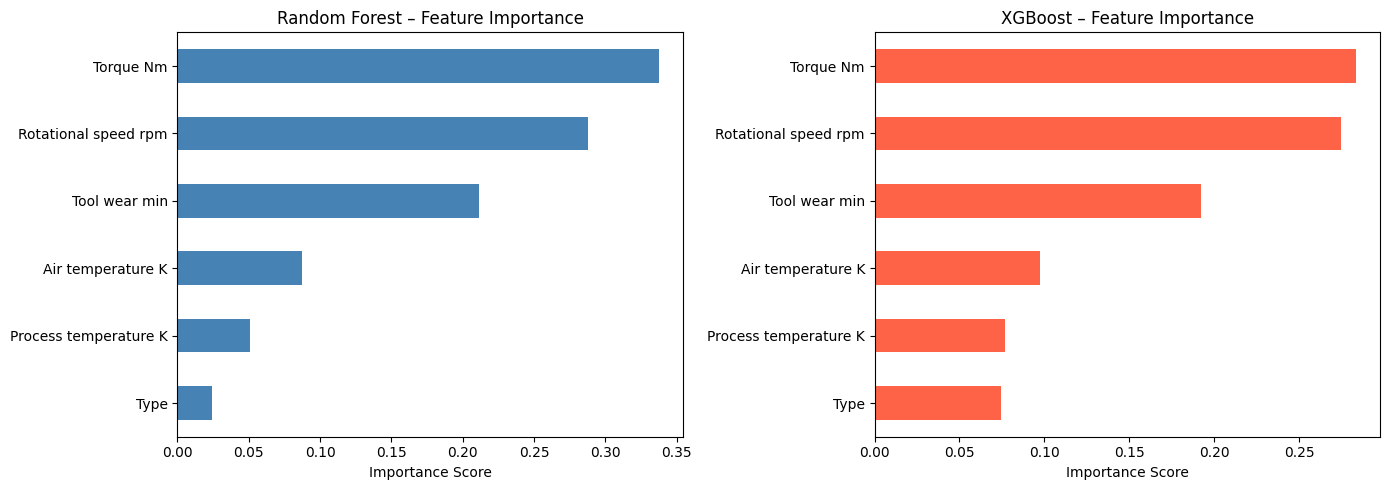

In [ ]:
feature_names = X.columns.tolist()

rf_importance  = pd.Series(rf.feature_importances_,         index=feature_names).sort_values(ascending=True)
xgb_importance = pd.Series(xgb_model.feature_importances_,  index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest – Feature Importance')
axes[0].set_xlabel('Importance Score')

xgb_importance.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('XGBoost – Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## Cell 12 – Model Comparison Summary


=== Model Comparison ===
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Random Forest     0.950     0.3919  0.8529     0.537   0.9738
XGBoost           0.974     0.5870  0.7941     0.675   0.9775


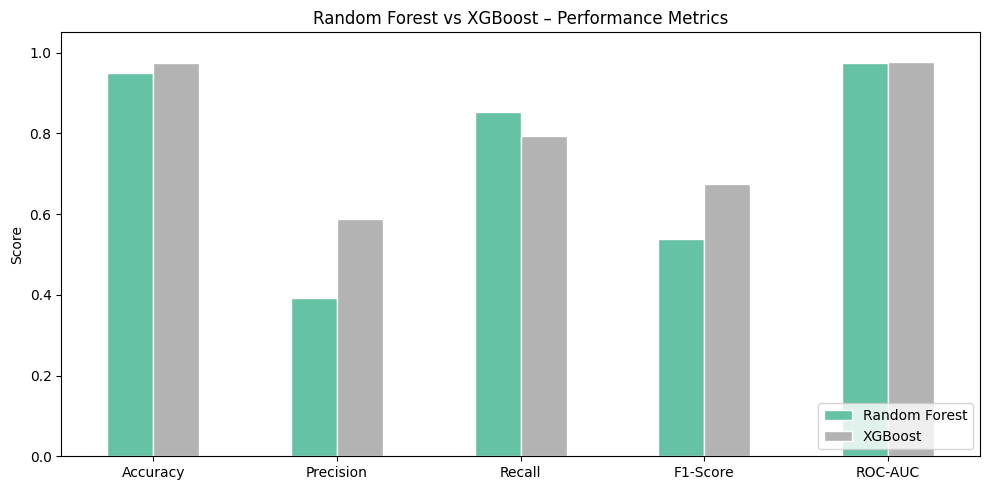

In [ ]:
results = {
    'Model':     ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred_xgb)],
    'F1-Score':  [f1_score(y_test, y_pred_rf),        f1_score(y_test, y_pred_xgb)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_rf),   roc_auc_score(y_test, y_prob_xgb)],
}

results_df = pd.DataFrame(results).set_index('Model').round(4)
print("\n=== Model Comparison ===")
print(results_df.to_string())

results_df.T.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Random Forest vs XGBoost – Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Cell 13 – Predict on New Data (Inference Example)

In [ ]:
# Simulate a new machine sensor reading
new_data = pd.DataFrame([{
    'Type': 1,                           # M = medium quality
    'Air temperature [K]': 298.5,
    'Process temperature [K]': 309.0,
    'Rotational speed [rpm]': 1450,
    'Torque [Nm]': 42.0,
    'Tool wear [min]': 190
}])

new_scaled = scaler.transform(new_data)

rf_pred  = rf.predict(new_scaled)[0]
rf_prob  = rf.predict_proba(new_scaled)[0][1]
xgb_pred = xgb_model.predict(new_scaled)[0]
xgb_prob = xgb_model.predict_proba(new_scaled)[0][1]

print("=== Maintenance Alert System ===")
print(f"  Random Forest → {'FAILURE PREDICTED' if rf_pred else 'Normal Operation'} (probability: {rf_prob:.2%})")
print(f"  XGBoost       → {'FAILURE PREDICTED' if xgb_pred else 'Normal Operation'} (probability: {xgb_prob:.2%})")

=== Maintenance Alert System ===
  Random Forest → ✅ Normal Operation (probability: 2.29%)
  XGBoost       → ✅ Normal Operation (probability: 0.65%)
